Cleaning 5572 real messages... This might take a minute.

Training Random Forest...
--- Random Forest Metrics ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115


Training XGBoost...


C:\Users\DELL\PyCharmMiscProject\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:06:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Metrics ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.84      0.90       150

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



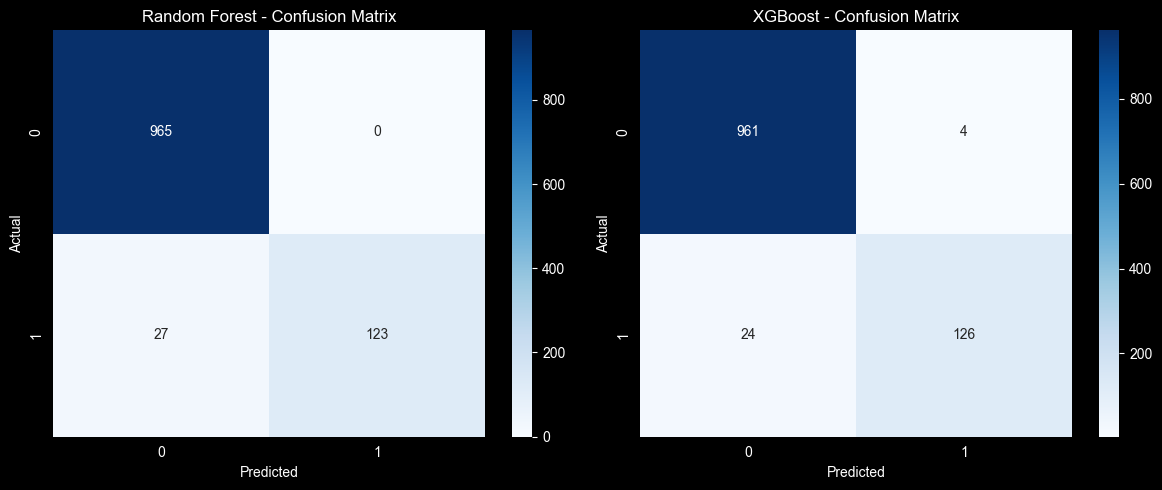

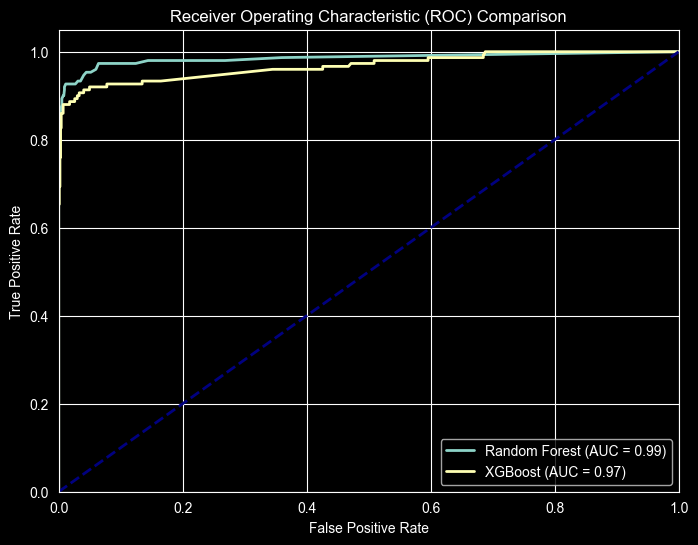


✅ Execution Complete! Models and visualizations have been saved.


In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Ensure NLTK downloads are available
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

class AdvancedSpamDetector:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=5000)
        self.models = {
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        }
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def preprocess_text(self, text):
        """Cleans text by removing special chars, converting to lowercase, and lemmatizing."""
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', str(text))
        text = text.lower()
        words = text.split()
        words = [self.lemmatizer.lemmatize(w) for w in words if w not in self.stop_words]
        return ' '.join(words)

    def load_and_prepare_data(self, filepath):
        """Loads Kaggle dataset, fixes encoding, and applies preprocessing."""
        # Real dataset ko latin-1 encoding ke saath read karna zaroori hai
        df = pd.read_csv(filepath, encoding='latin-1')

        # Kaggle data mein 5 columns aate hain, hume sirf pehle do (v1, v2) chahiye
        df = df[['v1', 'v2']]
        df.columns = ['label', 'text']

        # Labels ko 0 aur 1 mein convert karna
        df['label'] = df['label'].map({'spam': 1, 'ham': 0})

        print(f"Cleaning {len(df)} real messages... This might take a minute.")
        df['clean_text'] = df['text'].apply(self.preprocess_text)

        X = self.vectorizer.fit_transform(df['clean_text']).toarray()
        y = df['label'].values
        return train_test_split(X, y, test_size=0.2, random_state=42)

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        """Trains both models and displays comparative metrics."""
        plt.figure(figsize=(12, 5))

        for i, (name, model) in enumerate(self.models.items()):
            print(f"\nTraining {name}...")
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            # Print Metrics
            print(f"--- {name} Metrics ---")
            print(classification_report(y_test, predictions, zero_division=0))

            # Confusion Matrix Plot
            plt.subplot(1, 2, i+1)
            cm = confusion_matrix(y_test, predictions)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'{name} - Confusion Matrix')
            plt.ylabel('Actual')
            plt.xlabel('Predicted')

            # Save the best model components for the Web App
            if name == "XGBoost":
                joblib.dump(model, 'spam_model_xgb.pkl')
                joblib.dump(self.vectorizer, 'tfidf_vectorizer.pkl')

        plt.tight_layout()
        plt.savefig('confusion_matrices.png')
        plt.show()

        self._plot_roc_curves(X_test, y_test)

    def _plot_roc_curves(self, X_test, y_test):
        """Generates ROC curves for model comparison."""
        plt.figure(figsize=(8, 6))
        for name, model in self.models.items():
            probs = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Comparison')
        plt.legend(loc="lower right")
        plt.savefig('roc_curve.png')
        plt.show()

# Execution Block
if __name__ == "__main__":
    detector = AdvancedSpamDetector()
    try:
        # Load the real Kaggle file (Make sure spam.csv is in the same folder)
        X_train, X_test, y_train, y_test = detector.load_and_prepare_data('spam.csv')
        detector.train_and_evaluate(X_train, X_test, y_train, y_test)
        print("\n✅ Execution Complete! Models and visualizations have been saved.")
    except Exception as e:
        print(f"An error occurred during training: {e}")